In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
df = pd.read_csv("merged_data.csv")
df['Diabetes_Status'] = df['Diabetes_Status'].map({1:1, 2:0})
df = df.drop(columns=['SEQN'])
# df.hist(figsize=(20,20))
# from tabulate import tabulate

# nulls = df.isnull().sum().reset_index()
# nulls.columns = ['Column', 'Missing Values']
# print(tabulate(nulls, headers='keys', tablefmt='psql'))
# print(df.shape)

#CLEANING
df_clean = df.dropna()
df_clean = df_clean[(df_clean["Diabetes_Status"] != 3) & (df_clean["Diabetes_Status"] != 9)]
df_clean.describe()
# df_clean.hist(figsize=(20,20))
# print(df_clean.isnull().sum())
df_clean['Diabetes_Status'].value_counts()

Diabetes_Status
0.0    2785
1.0     382
Name: count, dtype: int64

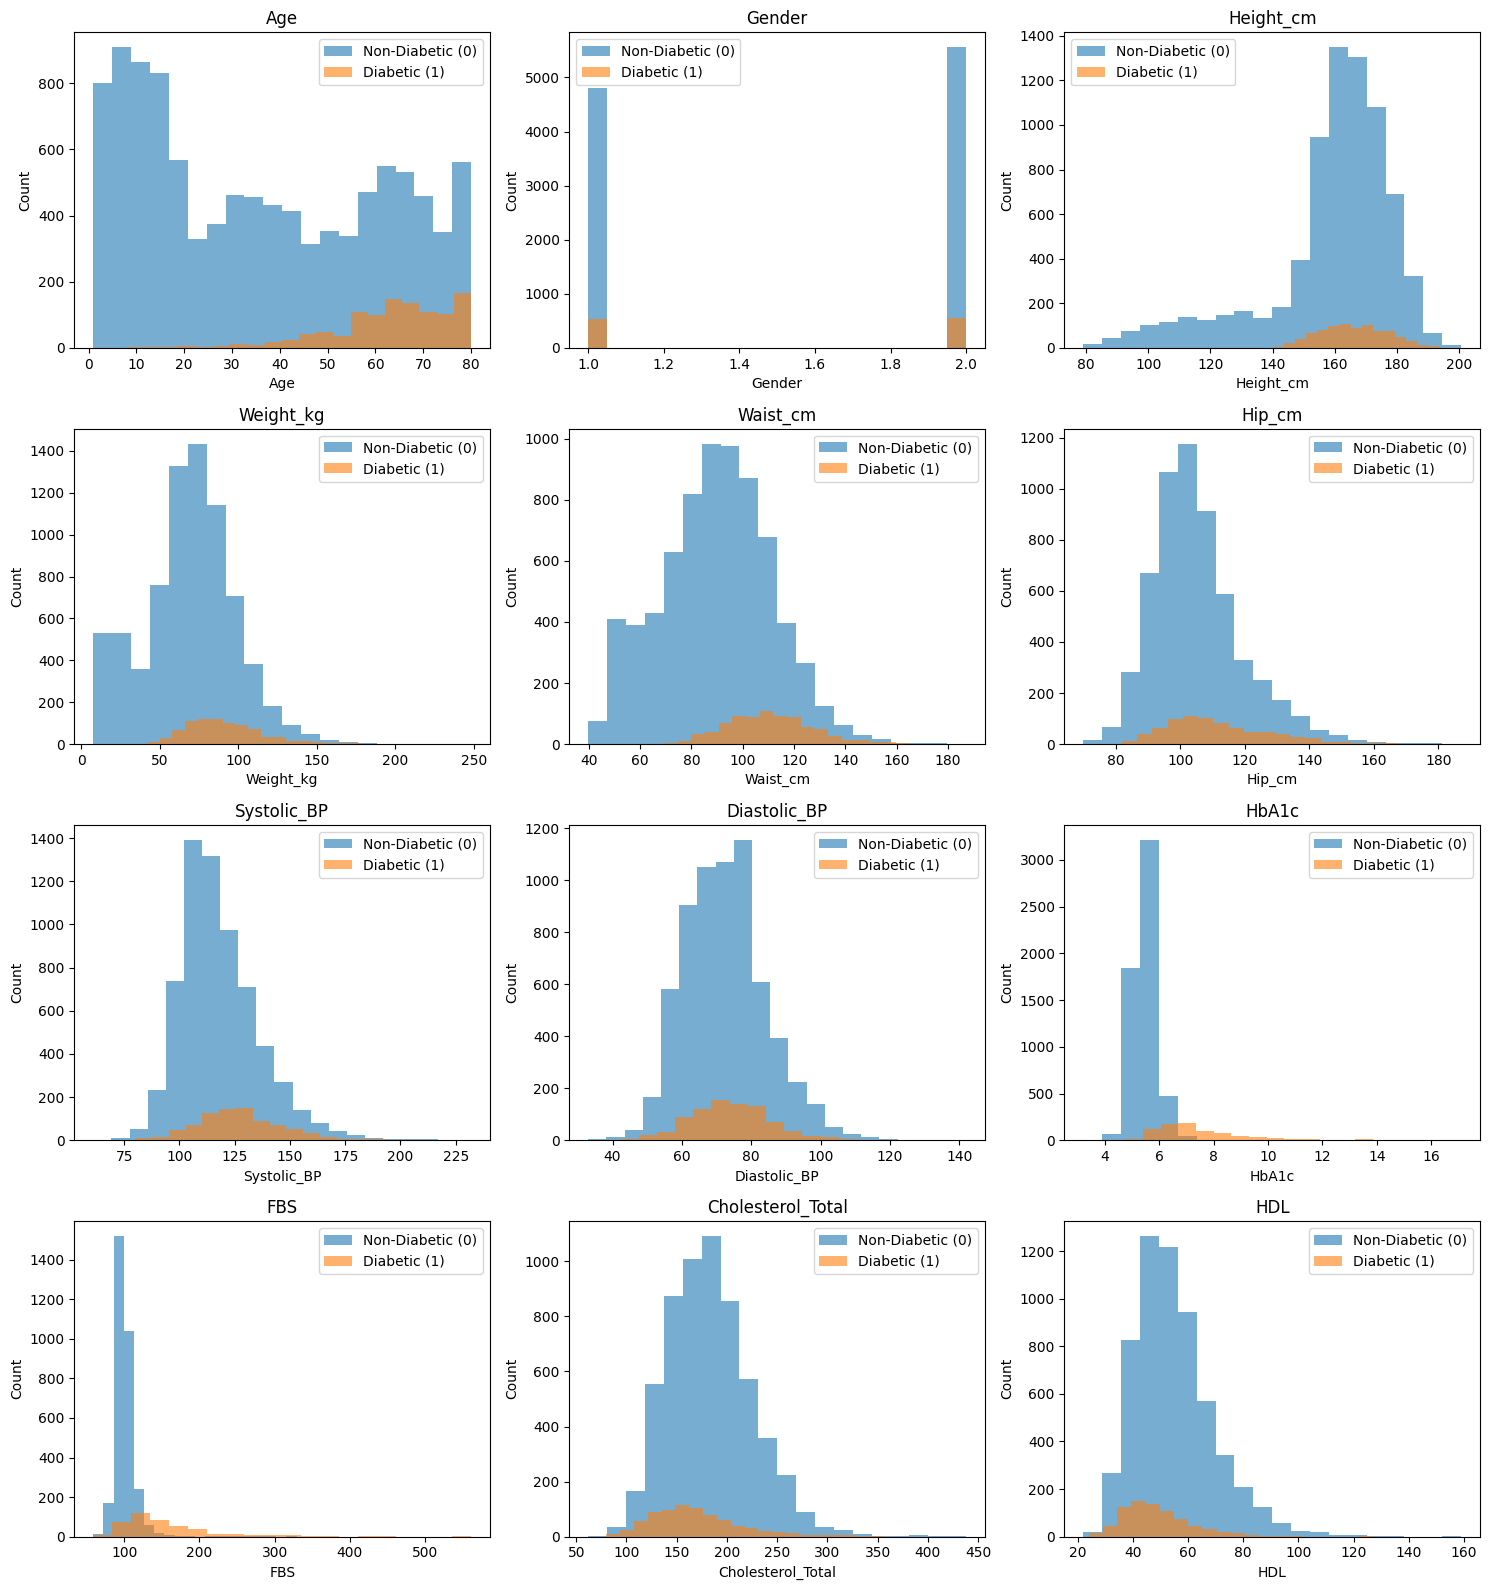

In [38]:
import matplotlib.pyplot as plt

target = "Diabetes_Status"
features = df_clean.drop(columns=[target]).columns

# create grid: adjust rows/cols depending on number of features
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols  # auto rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()  # make axes iterable

for i, col in enumerate(features):
    ax = axes[i]
    df[df[target] == 0][col].plot(kind="hist", bins=20, alpha=0.6, label="Non-Diabetic (0)", ax=ax)
    df[df[target] == 1][col].plot(kind="hist", bins=20, alpha=0.6, label="Diabetic (1)", ax=ax)

    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

# remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("diabetes_distributions.png", dpi=300)  # save image
plt.show()


<Axes: >

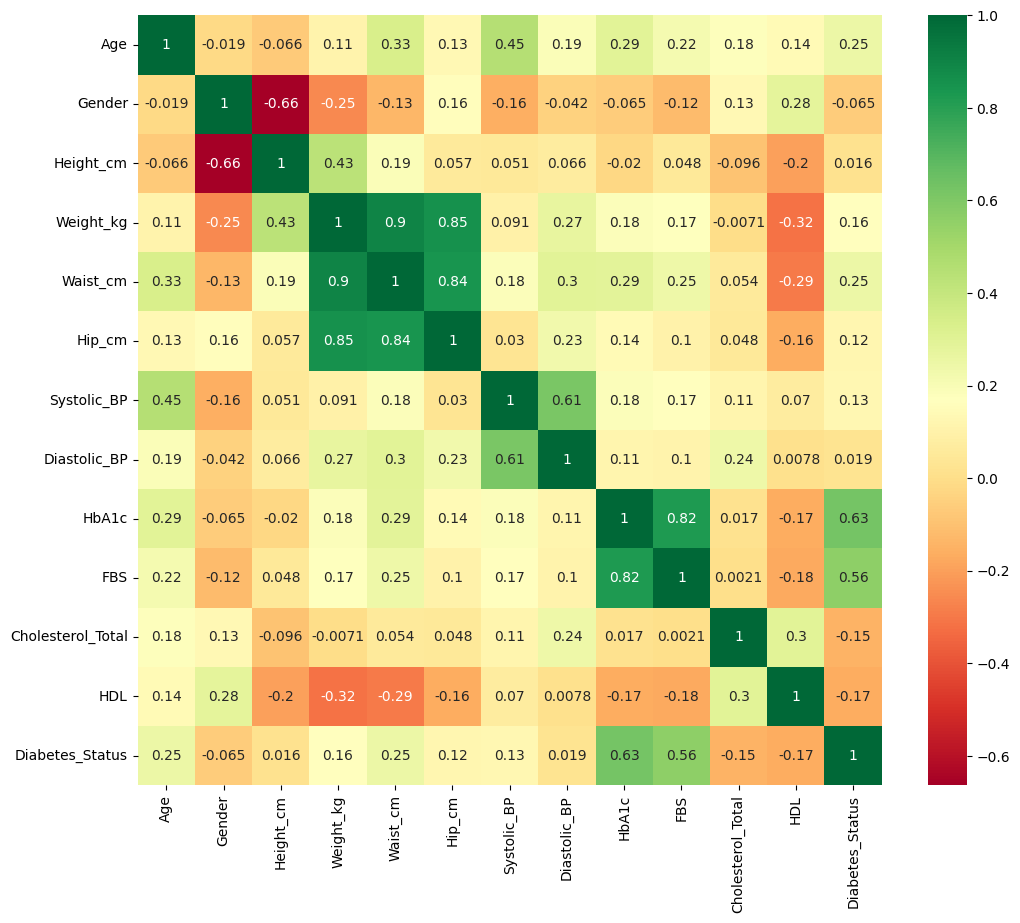

In [39]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='RdYlGn')

In [3]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["Diabetes_Status"])
y = df_clean["Diabetes_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train ratio:\n", X_train.value_counts(normalize=True))
print("Valid ratio:\n", X_test.value_counts(normalize=True))


Train ratio:
 Age   Gender  Height_cm  Weight_kg  Waist_cm  Hip_cm  Systolic_BP  Diastolic_BP  HbA1c  FBS    Cholesterol_Total  HDL 
12.0  1       136.7      39.0       69.5      77.6    96.0         70.0          5.2    105.0  126.0              43.0    0.000395
              148.6      46.7       72.2      72.2    113.0        68.0          5.0    100.0  174.0              35.0    0.000395
              148.8      53.1       86.4      89.1    111.0        73.0          5.0    104.0  216.0              50.0    0.000395
              152.7      62.4       90.5      97.5    94.0         62.0          5.2    96.0   184.0              51.0    0.000395
              154.5      58.8       91.5      90.3    108.0        61.0          5.2    94.0   151.0              47.0    0.000395
                                                                                                                            ...   
80.0  2       166.6      49.8       79.2      87.5    159.0        67.0          

In [41]:
train = pd.DataFrame(X_train, columns=X.columns)
train["Diabetes_Status"] = y_train

valid = pd.DataFrame(X_valid, columns=X.columns)
valid["Diabetes_Status"] = y_valid

test = pd.DataFrame(X_test, columns=X.columns)
test["Diabetes_Status"] = y_test

NameError: name 'X_valid' is not defined

In [ ]:
train['Diabetes_Status'].value_counts()
valid['Diabetes_Status'].value_counts()
test['Diabetes_Status'].value_counts()


,count
Diabetes_Status,
0.0,557
1.0,77


# **Raw Dataset Training**
all values are raw that contains NaN.

GENDER:
*   MALE: 1,
*   FEMALE: 2

DIABETES STATS:
*   YES: 1
*   NO: 0





# Feature Importance

Gini Importance

In [34]:
import shap
feature_names = df_clean.columns[:-1]
importances = logistic_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
print(feature_imp_df)

plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

AttributeError: 'LogisticRegression' object has no attribute 'feature_importances_'


🔍 Logistic Regression Feature Importance
              Feature  Coefficient  Abs_Coefficient
8               HbA1c     1.702094         1.702094
1              Gender     0.453423         0.453423
4            Waist_cm     0.052913         0.052913
0                 Age     0.035926         0.035926
9                 FBS     0.030236         0.030236
11                HDL    -0.019271         0.019271
3           Weight_kg    -0.019137         0.019137
5              Hip_cm    -0.012745         0.012745
10  Cholesterol_Total    -0.011429         0.011429
6         Systolic_BP    -0.004486         0.004486
2           Height_cm    -0.002561         0.002561
7        Diastolic_BP    -0.002131         0.002131


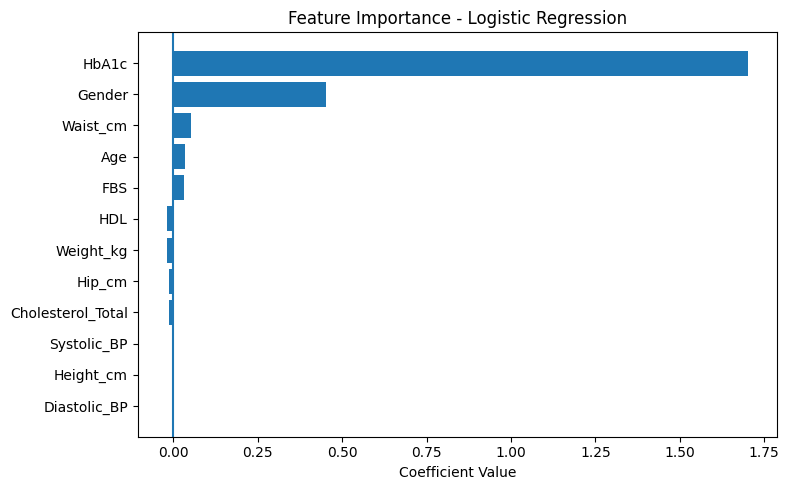

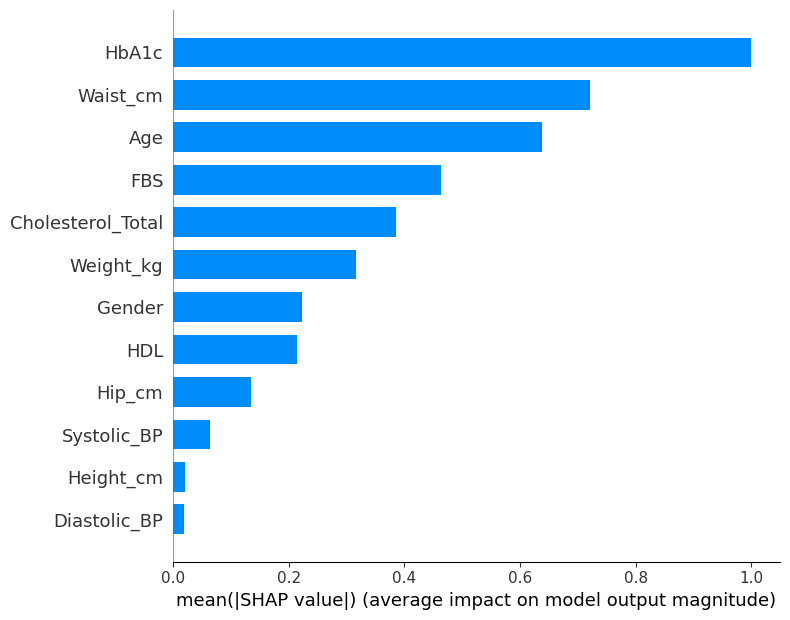

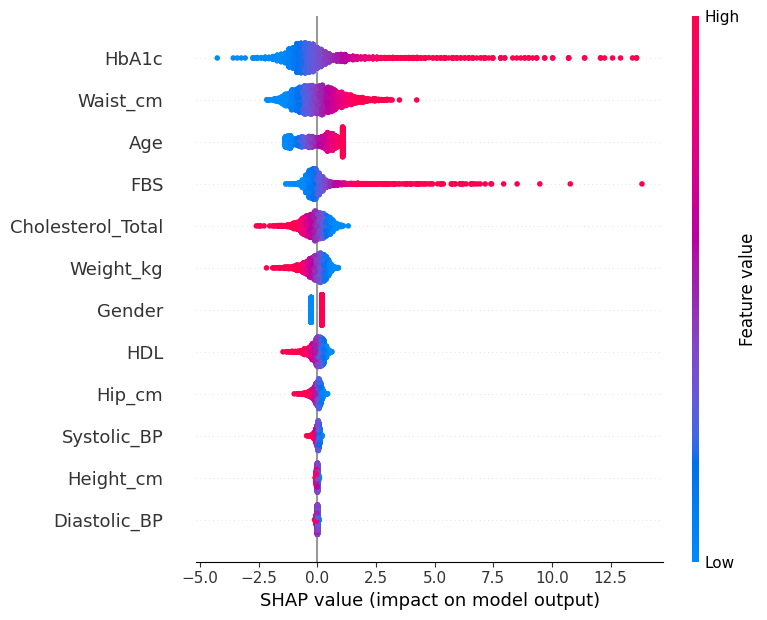

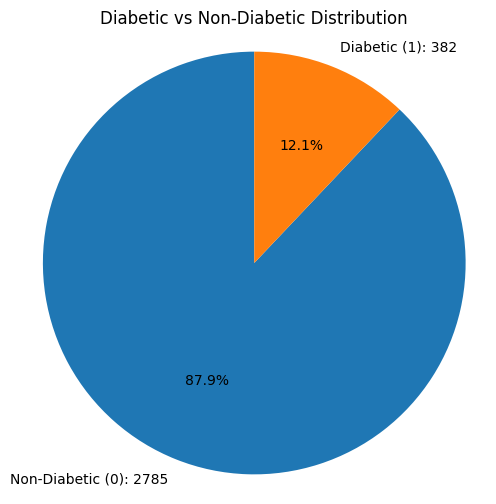

In [24]:
import matplotlib.pyplot as plt

# Target column
target = "Diabetes_Status"

# Count values
counts = df_clean[target].value_counts().sort_index()

labels = ["Non-Diabetic (0)", "Diabetic (1)"]
sizes = counts.values

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=[f"{labels[i]}: {sizes[i]}" for i in range(len(sizes))],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Diabetic vs Non-Diabetic Distribution")
plt.axis('equal')
plt.show()

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_auc_score, precision_score, accuracy_score, f1_score

In [36]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Split features and target
X = df_clean.drop(columns=['Diabetes_Status'])   # change target name if needed
y = df_clean['Diabetes_Status']

# Train Random Forest
logistic_model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=0.1,
        class_weight='balanced'
    )
logistic_model.fit(X, y)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'



🔍 Logistic Regression Feature Importance
              Feature  Coefficient  Abs_Coefficient
8               HbA1c     1.702094         1.702094
1              Gender     0.453423         0.453423
4            Waist_cm     0.052913         0.052913
0                 Age     0.035926         0.035926
9                 FBS     0.030236         0.030236
11                HDL    -0.019271         0.019271
3           Weight_kg    -0.019137         0.019137
5              Hip_cm    -0.012745         0.012745
10  Cholesterol_Total    -0.011429         0.011429
6         Systolic_BP    -0.004486         0.004486
2           Height_cm    -0.002561         0.002561
7        Diastolic_BP    -0.002131         0.002131


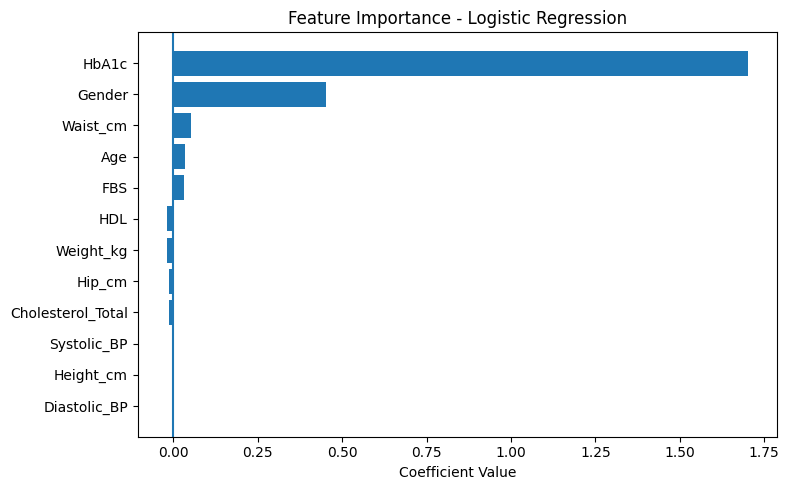

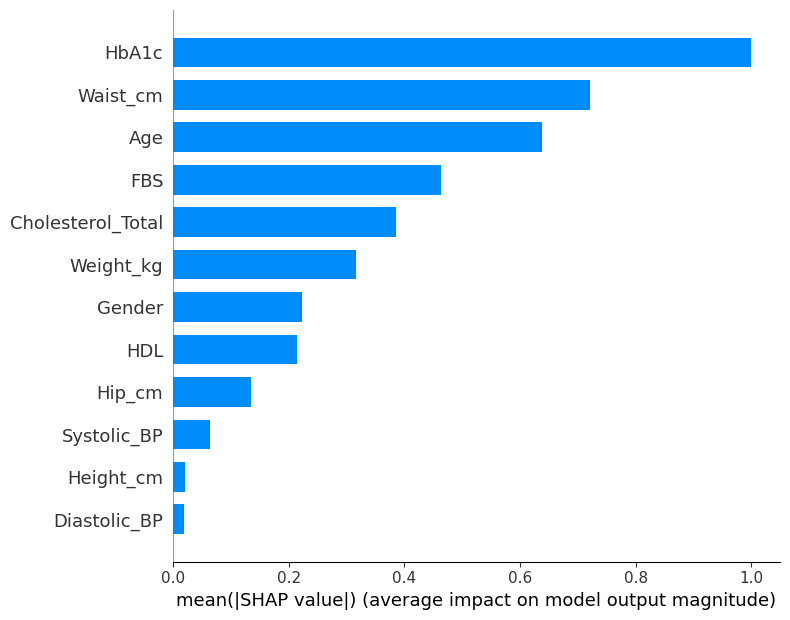

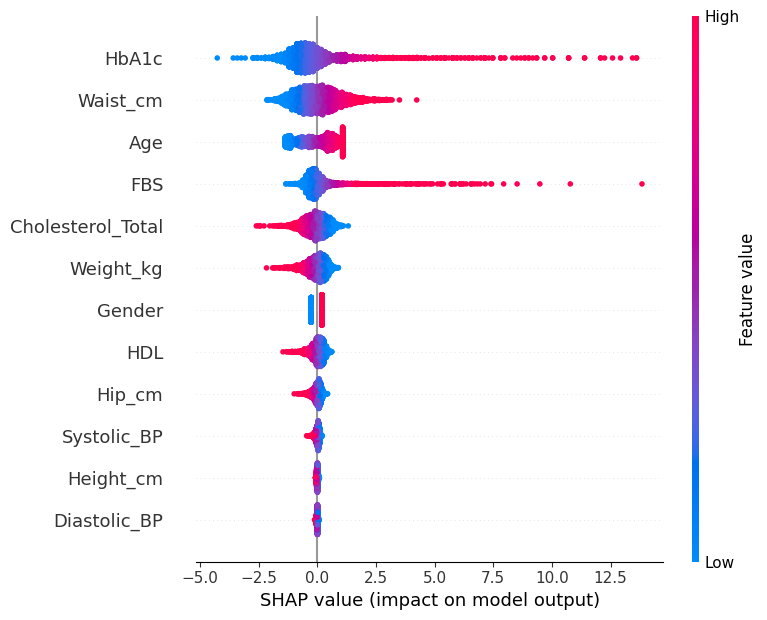

In [37]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# =========================
# FEATURE NAMES
# =========================
target = "Diabetes_Status"   # change if needed
feature_names = df_clean.drop(columns=[target]).columns

# =========================
# LOGISTIC REGRESSION COEFFICIENTS
# =========================
coefficients = logistic_model.coef_[0]

feature_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values(by="Abs_Coefficient", ascending=False)

print("\n🔍 Logistic Regression Feature Importance")
print(feature_imp_df)

# =========================
# BAR PLOT
# =========================
plt.figure(figsize=(8, 5))
plt.barh(
    feature_imp_df["Feature"],
    feature_imp_df["Coefficient"]
)
plt.axvline(0)
plt.xlabel("Coefficient Value")
plt.title("Feature Importance - Logistic Regression")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# =========================
# OPTIONAL: SHAP FEATURE IMPORTANCE
# =========================
# Use training data (NOT SMOTE output)
X_shap = df_clean.drop(columns=[target])

explainer = shap.LinearExplainer(logistic_model, X_shap)
shap_values = explainer.shap_values(X_shap)

# SHAP bar plot (global importance)
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

# SHAP beeswarm (effect + direction)
shap.summary_plot(
    shap_values,
    X_shap
)

# TRAINING

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_auc_score, precision_score, accuracy_score, f1_score

In [5]:
numeric_features = X_train.columns.tolist()

over = SMOTE()
under = RandomUnderSampler()

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)

preprocessor_SMOTE = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)
print(numeric_features)

['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Waist_cm', 'Hip_cm', 'Systolic_BP', 'Diastolic_BP', 'HbA1c', 'FBS', 'Cholesterol_Total', 'HDL']


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
}

xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC:", grid_search.best_score_)


Fitting 3 folds for each of 81 candidates, totalling 243 fits


KeyboardInterrupt: 

In [ ]:
def train_and_evaluate_model_SMOTE(models, X_train, y_train, X_valid, y_valid):
    """
    Enhanced version that returns model performance for comparison
    """
    results = {}

    for name, model in models.items():
        print(f"\n🔹 Training {name}...")

        if name == "Random Forest" or name == "XGBoost":
          pipe = ImbPipeline([
              ('over', over),
              ('under', under),
              ('model', model)
          ])
        else:
          pipe = ImbPipeline([
              ('preprocess', preprocessor),
              ('over', over),
              ('under', under),
              ('model', model)
          ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_valid)
        y_proba = pipe.predict_proba(X_valid)[:, 1]

        # Calculate multiple metrics
        roc_auc = roc_auc_score(y_valid, y_proba)
        accuracy = accuracy_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred, zero_division=0)
        recall = recall_score(y_valid, y_pred, zero_division=0)
        f1 = f1_score(y_valid, y_pred, zero_division=0)

        # Store results
        results[name] = {
            'model': pipe,
            'roc_auc': roc_auc,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'predictions': y_pred,
            'probabilities': y_proba
        }

        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_valid, y_pred, digits=2))

        cm = confusion_matrix(y_valid, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

    return results

# Usage
results = train_and_evaluate_model_SMOTE(models, X_train, y_train, X_test, y_test)

# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']

print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")


🔹 Training Logistic Regression...
ROC-AUC: 0.9777
F1-Score: 0.7157
              precision    recall  f1-score   support

         0.0       0.99      0.90      0.95       558
         1.0       0.57      0.96      0.72        76

    accuracy                           0.91       634
   macro avg       0.78      0.93      0.83       634
weighted avg       0.94      0.91      0.92       634



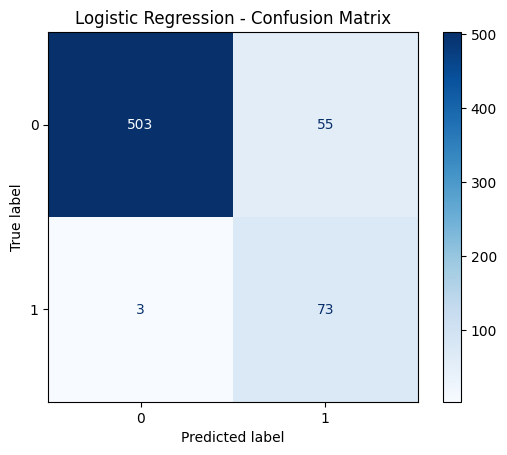


🔹 Training Random Forest...
ROC-AUC: 0.9654
F1-Score: 0.7168
              precision    recall  f1-score   support

         0.0       0.97      0.94      0.96       558
         1.0       0.64      0.82      0.72        76

    accuracy                           0.92       634
   macro avg       0.81      0.88      0.84       634
weighted avg       0.93      0.92      0.93       634



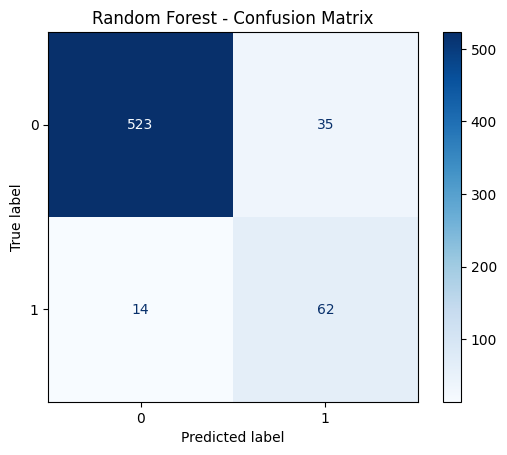


🔹 Training KNN...
ROC-AUC: 0.9166
F1-Score: 0.6939
              precision    recall  f1-score   support

         0.0       0.98      0.91      0.94       558
         1.0       0.57      0.89      0.69        76

    accuracy                           0.91       634
   macro avg       0.78      0.90      0.82       634
weighted avg       0.93      0.91      0.91       634



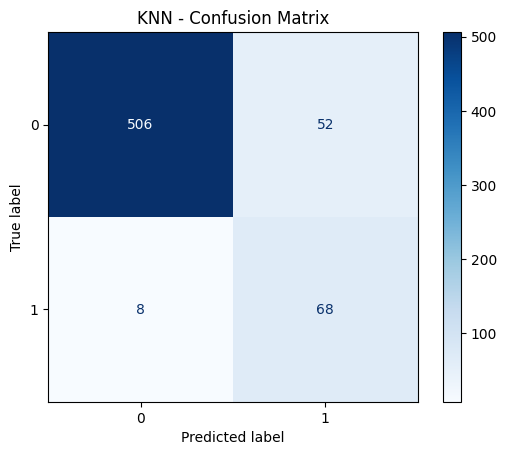


🔹 Training Naive Bayes...
ROC-AUC: 0.9660
F1-Score: 0.7174
              precision    recall  f1-score   support

         0.0       0.98      0.92      0.95       558
         1.0       0.61      0.87      0.72        76

    accuracy                           0.92       634
   macro avg       0.80      0.90      0.83       634
weighted avg       0.94      0.92      0.92       634



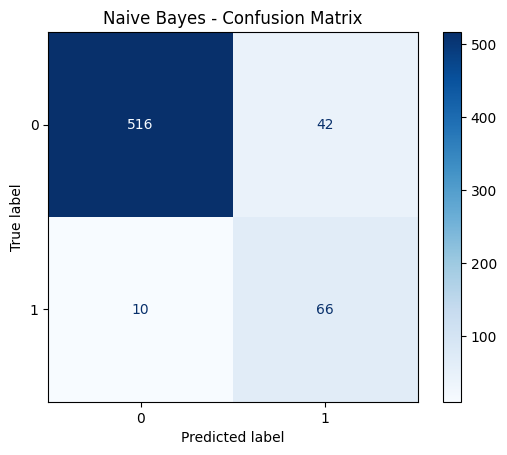


🔹 Training SVM...
ROC-AUC: 0.9687
F1-Score: 0.7021
              precision    recall  f1-score   support

         0.0       0.98      0.92      0.95       558
         1.0       0.59      0.87      0.70        76

    accuracy                           0.91       634
   macro avg       0.79      0.89      0.83       634
weighted avg       0.93      0.91      0.92       634



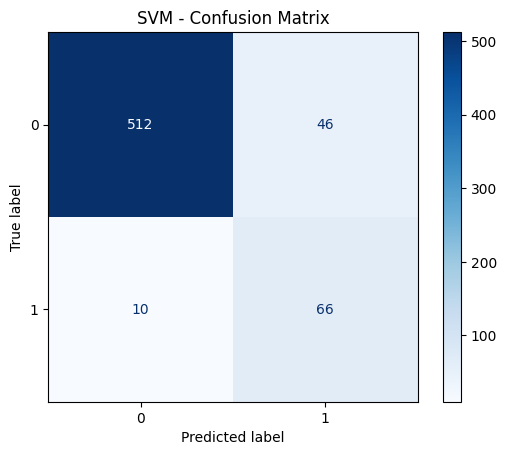


🔹 Training XGBoost...


c:\REPOS\thesis_diabetes\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:01:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC: 0.9582
F1-Score: 0.7037
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96       558
         1.0       0.66      0.75      0.70        76

    accuracy                           0.92       634
   macro avg       0.81      0.85      0.83       634
weighted avg       0.93      0.92      0.93       634



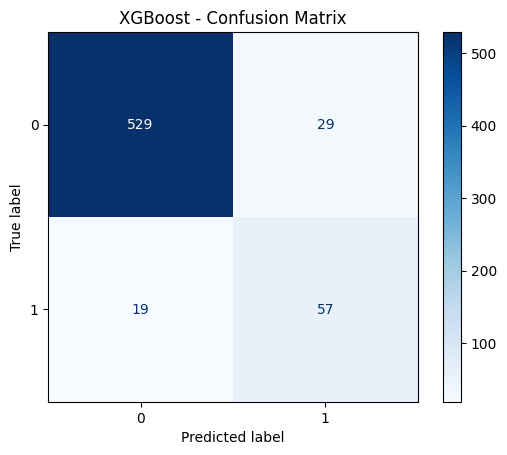

c:\REPOS\thesis_diabetes\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

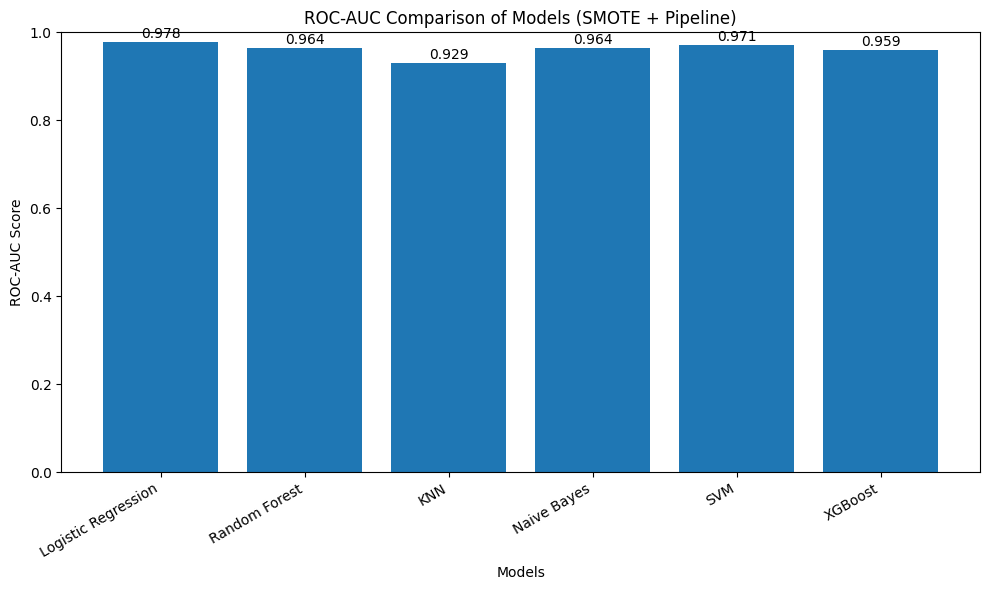

In [13]:
import matplotlib.pyplot as plt

# Extract model names and ROC-AUC scores
model_names = list(results.keys())
roc_auc_scores = [results[name]['roc_auc'] for name in model_names]

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(model_names, roc_auc_scores)

# Labels and title
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")
plt.title("ROC-AUC Comparison of Models (SMOTE + Pipeline)")
plt.ylim(0.0, 1.0)

# Rotate x labels for readability
plt.xticks(rotation=30, ha='right')

# Annotate bars with values
for i, score in enumerate(roc_auc_scores):
    plt.text(i, score + 0.01, f"{score:.3f}", ha='center')

plt.tight_layout()
plt.show()



🔹 Training Logistic Regression 2...
ROC-AUC: nan
F1-Score: 0.9241
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.86      0.92       163

    accuracy                           0.86       163
   macro avg       0.50      0.43      0.46       163
weighted avg       1.00      0.86      0.92       163



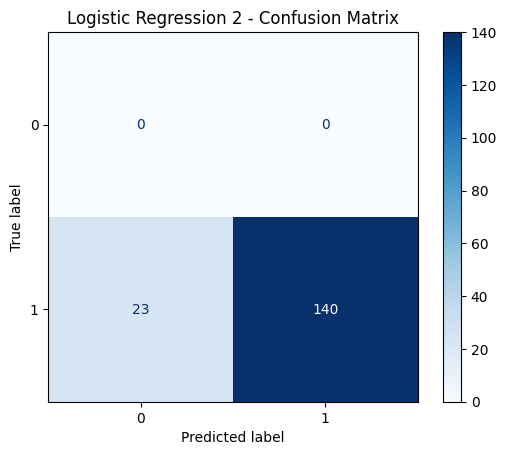

{'Logistic Regression 2': {'model': Pipeline(steps=[('preprocess',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('num', StandardScaler(),
                                                    ['Age', 'Gender', 'Weight_kg',
                                                     'Systolic_BP',
                                                     'Diastolic_BP', 'HbA1c',
                                                     'FBS', 'Cholesterol_Total',
                                                     'HDL'])])),
                  ('over', SMOTE()), ('under', RandomUnderSampler()),
                  ('model',
                   LogisticRegression(C=0.1, class_weight='balanced',
                                      max_iter=1000, random_state=42))]),
  'roc_auc': nan,
  'accuracy': 0.8588957055214724,
  'precision': 1.0,
  'recall': 0.8588957055214724,
  'f1_score': 0.9240924092409241,
  'predictions': array([1., 1., 0., 1.,

In [88]:
from sklearn.model_selection import train_test_split
df = pd.read_csv("merged_data.csv")
df['Diabetes_Status'] = df['Diabetes_Status'].map({1:1, 2:0})
df = df.drop(columns=['SEQN'])
# df.hist(figsize=(20,20))
# from tabulate import tabulate

# nulls = df.isnull().sum().reset_index()
# nulls.columns = ['Column', 'Missing Values']
# print(tabulate(nulls, headers='keys', tablefmt='psql'))
# print(df.shape)

#CLEANING
df_clean = df.dropna()
df_clean = df_clean[(df_clean["Diabetes_Status"] != 3) & (df_clean["Diabetes_Status"] != 9)]
df_clean.drop(columns=['Waist_cm', 'Hip_cm', 'Height_cm'], inplace=True)

X_train = df_clean.drop(columns=["Diabetes_Status"])
y_train = df_clean["Diabetes_Status"]

df_ccmc = pd.read_excel('ccmc_dataset/COMPILED_DATASET.xlsx')
df_ccmc.drop(columns=['STATUS', 'SGOT', 'SGPT', 'VLDL', 'LDL', 'TG', 'RBS'], inplace=True)


df_ccmc = df_ccmc.dropna(subset=['HbA1c'])
df_ccmc['Gender'] = df_ccmc['Gender'].map({'M': 1, 'F': 2})
numeric_cols = df_ccmc.select_dtypes(include=['float64', 'int64']).columns

df_ccmc[numeric_cols] = df_ccmc[numeric_cols].fillna(df_ccmc[numeric_cols].mean())
X_test = df_ccmc.drop(columns=["Diabetes_Status"])
y_test = df_ccmc["Diabetes_Status"]




models_lg = {
    "Logistic Regression 2": LogisticRegression(max_iter=1000,
                                                random_state=42,
                                                penalty='l2',
                                                C=0.1,
                                                class_weight='balanced'),
}

train_and_evaluate_model_SMOTE(models_lg, X_train, y_train, X_test, y_test)



In [75]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3167 entries, 0 to 11931
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                3167 non-null   float64
 1   Gender             3167 non-null   float64
 2   Height_cm          3167 non-null   float64
 3   Weight_kg          3167 non-null   float64
 4   Systolic_BP        3167 non-null   float64
 5   Diastolic_BP       3167 non-null   float64
 6   HbA1c              3167 non-null   float64
 7   FBS                3167 non-null   float64
 8   Cholesterol_Total  3167 non-null   float64
 9   HDL                3167 non-null   float64
dtypes: float64(10)
memory usage: 272.2 KB


In [76]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 163 entries, 0 to 1251
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                163 non-null    float64
 1   Gender             163 non-null    float64
 2   Systolic_BP        163 non-null    float64
 3   Diastolic_BP       163 non-null    float64
 4   FBS                163 non-null    float64
 5   Cholesterol_Total  163 non-null    float64
 6   HDL                163 non-null    float64
 7   HbA1c              163 non-null    float64
 8   Weight_kg          163 non-null    float64
dtypes: float64(9)
memory usage: 12.7 KB


In [ ]:
df_ccmc = pd.read_excel('ccmc_dataset/COMPILED_DATASET.xlsx')
df_ccmc.drop(columns=['STATUS', 'SGOT', 'SGPT', 'VLDL', 'LDL', 'TG', 'RBS',], inplace=True)
df_ccmc.head()

X_train.head


,Age,Gender,Systolic_BP,Diastolic_BP,FBS,Cholesterol_Total,HDL,HbA1c,Weight_kg,Diabetes_Status
0,55.0,F,120.0,70.0,16.09,5.18,1.21,11.00,NaN,1
1,37.0,F,120.0,70.0,NaN,NaN,NaN,NaN,NaN,1
2,60.0,F,110.0,70.0,12.20,5.25,1.05,8.88,NaN,1
3,51.0,F,100.0,70.0,4.99,NaN,NaN,4.80,NaN,1
4,74.0,NaN,110.0,80.0,8.20,4.60,0.95,10.10,NaN,1



🔹 Training Logistic Regression 2...
ROC-AUC: 0.9784
F1-Score: 0.7273
              precision    recall  f1-score   support

         0.0       0.99      0.91      0.95       558
         1.0       0.59      0.95      0.73        76

    accuracy                           0.91       634
   macro avg       0.79      0.93      0.84       634
weighted avg       0.94      0.91      0.92       634



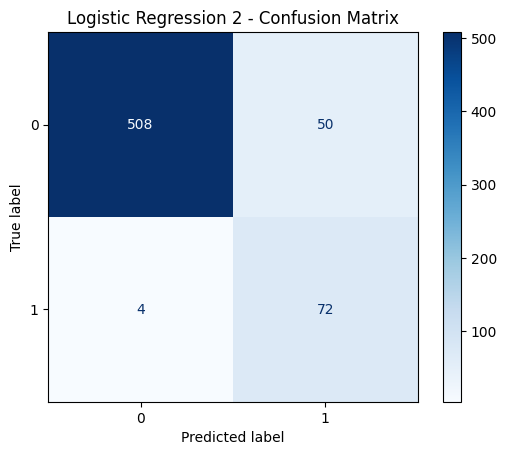

{'Logistic Regression 2': {'model': Pipeline(steps=[('preprocess',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('num', StandardScaler(),
                                                    ['Age', 'Gender', 'Height_cm',
                                                     'Weight_kg', 'Waist_cm',
                                                     'Hip_cm', 'Systolic_BP',
                                                     'Diastolic_BP', 'HbA1c',
                                                     'FBS', 'Cholesterol_Total',
                                                     'HDL'])])),
                  ('over', SMOTE()), ('under', RandomUnderSampler()),
                  ('model',
                   LogisticRegression(C=0.1, class_weight='balanced',
                                      max_iter=1000, random_state=42))]),
  'roc_auc': np.float64(0.9784003018298434),
  'accuracy': 0.9148264984227129,
  'precisi

In [ ]:
df_ccmc = pd.read_excel('ccmc_dataset/COMPILED_DATASET.xlsx')
df_ccmc.head()
models_lg = {
    "Logistic Regression 2": LogisticRegression(max_iter=1000,
                                                random_state=42,
                                                penalty='l2',
                                                C=0.1,
                                                class_weight='balanced'),
}

train_and_evaluate_model_SMOTE(models_lg, X_train, y_train, X_test, y_test)



🔹 Training XGBoost...
ROC-AUC: 0.9592
F1-Score: 0.7547
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96       558
         1.0       0.72      0.79      0.75        76

    accuracy                           0.94       634
   macro avg       0.85      0.87      0.86       634
weighted avg       0.94      0.94      0.94       634



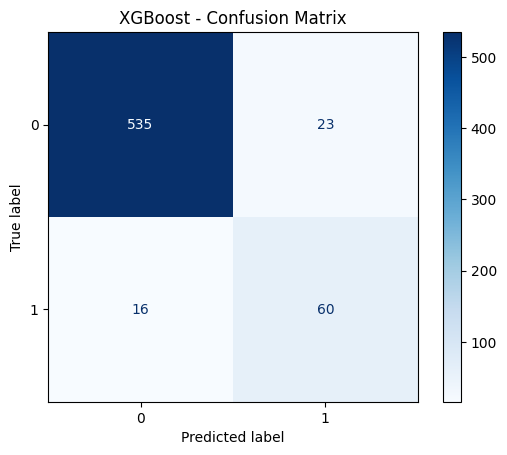

{'XGBoost': {'model': Pipeline(steps=[('over', SMOTE()), ('under', RandomUnderSampler()),
                  ('model',
                   XGBClassifier(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=None, device=None,
                                 early_stopping_rounds=None,
                                 enable_categorical=False, eval_metric='logloss',
                                 feature_types=None, feature_weights=None,
                                 gamma=None, grow_policy=None,
                                 importance_type=None,
                                 interaction_constraints=None, learning_rate=None,
                                 max_bin=None, max_cat_threshold=None,
                                 max_cat_to_onehot=None, max_delta_step=None,
                                 max_depth=None, max_leaves=None,
                   

In [ ]:
models_xg = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=100)
}

train_and_evaluate_model_SMOTE(models_xg, X_train, y_train, X_test, y_test)


In [ ]:


param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best ROC-AUC: 0.9450001170058757


In [7]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', over),
    ('under', under),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=0.1,
        class_weight='balanced'
    ))
])

best_pipe.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('over', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', over),
    ('under', under),
    ('model', LogisticRegression(max_iter=1000,
                                                random_state=42,
                                                penalty='l2',
                                                C=0.1,
                                                class_weight='balanced'
    ))
])

best_pipe.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('over', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
new_patient = pd.DataFrame([{
    'Age': 54,                # Increased age (T2D risk increases with age)
    'Gender': 2,
    'Height_cm': 168,
    'Weight_kg': 98,        # BMI approx 30 (Obese category)
    'Waist_cm': 98,       # Realistic "at-risk" waist circumference (>40 inches)
    'Hip_cm': 96,
    'Systolic_BP': 135,       # Higher hypertension (common comorbidity)
    'Diastolic_BP': 98,
    'HbA1c': 5.7,             # Clearly in the Diabetic range (>6.5)
    'FBS': 65,               # Clearly in the Diabetic range (>126)
    'Cholesterol_Total': 108, # Elevated cholesterol
    'HDL': 35                 # Lowered HDL (common in diabetic dyslipidemia)
}])

prob = best_pipe.predict_proba(new_patient)[0]
print(f"Predicted Probability of No Diabetes: {prob[0]*100:.2f}%")
print(f"Predicted Probability of Diabetes: {prob[1]*100:.2f}%")


# 1. Access the model from the pipeline
model = best_pipe.named_steps['model']

# 2. Get the feature names after preprocessing
# (Assuming your preprocessor is a ColumnTransformer)
feature_names = best_pipe.named_steps['preprocess'].get_feature_names_out()

# 3. Transform the patient data using the pipeline's preprocessing steps
# This ensures the data is scaled exactly how the model expects it
new_patient_transformed = best_pipe.named_steps['preprocess'].transform(new_patient)

# 4. Calculate contributions: (Transformed Value) * (Model Coefficient)
weights = model.coef_[0]
contributions = weights * new_patient_transformed[0]

# 5. Create the Impact DataFrame
impact_df = pd.DataFrame({
    'Feature': feature_names,
    'Impact': contributions
})

# Sort to see the biggest drivers of Diabetes (Positive Impact)
impact_df = impact_df.sort_values(by='Impact', ascending=False)
print(impact_df)

top_risks = impact_df.head(3)

print(f"Your Risk Summary:")
for index, row in top_risks.iterrows():
    # Clean up feature names (e.g., 'remainder__HbA1c' -> 'HbA1c')
    clean_name = row['Feature'].split('__')[-1]
    print(f" - {clean_name} is significantly increasing your risk score.")

Predicted Probability of No Diabetes: 79.26%
Predicted Probability of Diabetes: 20.74%
                   Feature    Impact
10  num__Cholesterol_Total  0.793444
11                num__HDL  0.293979
5              num__Hip_cm  0.279296
1              num__Gender  0.271662
0                 num__Age  0.164900
8               num__HbA1c  0.055191
2           num__Height_cm -0.009922
4            num__Waist_cm -0.017924
6         num__Systolic_BP -0.045900
7        num__Diastolic_BP -0.113929
3           num__Weight_kg -0.217545
9                 num__FBS -1.212327
Your Risk Summary:
 - Cholesterol_Total is significantly increasing your risk score.
 - HDL is significantly increasing your risk score.
 - Hip_cm is significantly increasing your risk score.


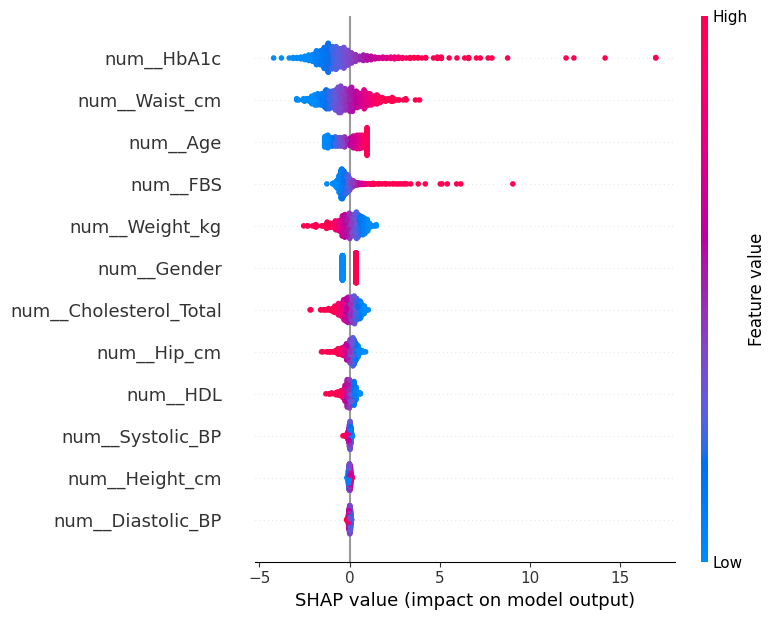

In [ ]:
import shap
import matplotlib.pyplot as plt

# Get preprocessed data (apply same transformations used during training)
X_test_preprocessed = best_model.named_steps['preprocess'].transform(X_test)

# Get the logistic regression model itself
log_reg = best_model.named_steps['model']

# Initialize SHAP explainer for linear models
explainer = shap.Explainer(log_reg, X_test_preprocessed)

# Compute SHAP values
shap_values = explainer(X_test_preprocessed)

# Get feature names after preprocessing
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

# Plot overall feature importance (global)
shap.summary_plot(shap_values, features=X_test_preprocessed, feature_names=feature_names)



🔹 Training Random Forest...
0.9676603987527166
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       557
         1.0       0.77      0.80      0.79        76

    accuracy                           0.95       633
   macro avg       0.87      0.89      0.88       633
weighted avg       0.95      0.95      0.95       633



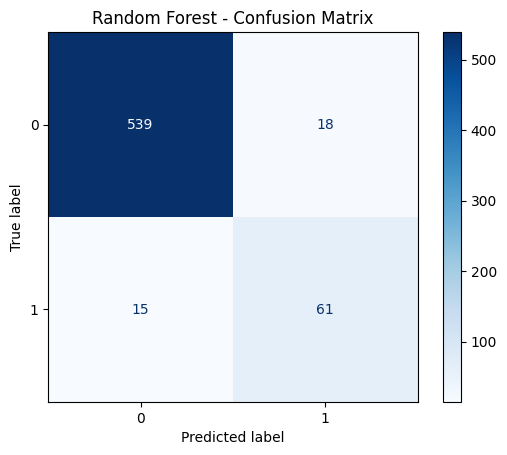

In [ ]:
models_RF = {
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42)
  }

train_and_evaluate_model(models_RF, X_train, y_train, X_valid, y_valid)

In [ ]:
pipe = ImbPipeline([
    ('oversample', RandomOverSampler()),
    ('model', RandomForestClassifier(random_state=42))
])

# Define parameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 5, 10, 20]
}

# Grid search (oversampling occurs correctly inside each fold)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# ✅ Fit on the *original* imbalanced data
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'model__max_depth': 20, 'model__n_estimators': 300}
Best ROC-AUC: 0.9501132155507097


# WITHOUT GLUCOSE LEVELS MODEL

In case the user does not know any other features.

In [ ]:
df_clean.columns
df_nogc = df_clean.drop(['HbA1c', 'FBS', 'Cholesterol_Total', 'HDL'], axis=1)
df_nogc.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Waist_cm', 'Hip_cm',
       'Systolic_BP', 'Diastolic_BP', 'Diabetes_Status'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

X = df_nogc.drop(columns=["Diabetes_Status"])
y = df_nogc["Diabetes_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)




🔹 Training Logistic Regression...
ROC-AUC: 0.7942
F1-Score: 0.3822
              precision    recall  f1-score   support

         0.0       0.96      0.68      0.80       558
         1.0       0.25      0.79      0.38        76

    accuracy                           0.69       634
   macro avg       0.61      0.74      0.59       634
weighted avg       0.87      0.69      0.75       634



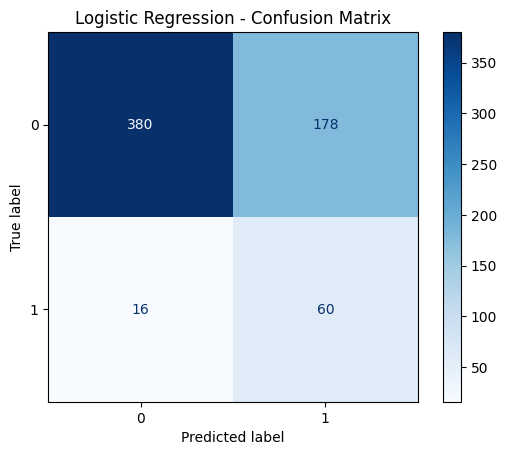


🔹 Training Random Forest...
ROC-AUC: 0.7666
F1-Score: 0.3103
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89       558
         1.0       0.28      0.36      0.31        76

    accuracy                           0.81       634
   macro avg       0.59      0.61      0.60       634
weighted avg       0.83      0.81      0.82       634



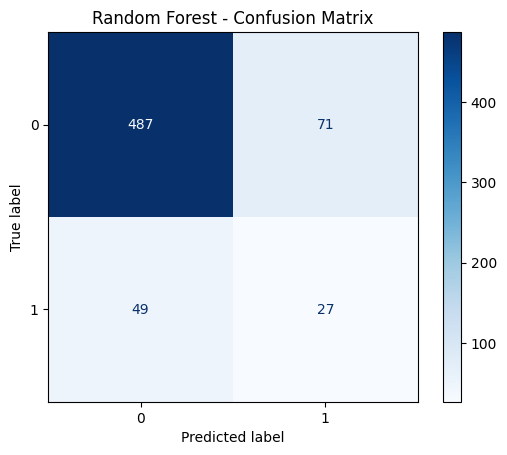


🔹 Training KNN...
ROC-AUC: 0.7372
F1-Score: 0.3525
              precision    recall  f1-score   support

         0.0       0.94      0.73      0.82       558
         1.0       0.24      0.64      0.35        76

    accuracy                           0.72       634
   macro avg       0.59      0.69      0.59       634
weighted avg       0.85      0.72      0.76       634



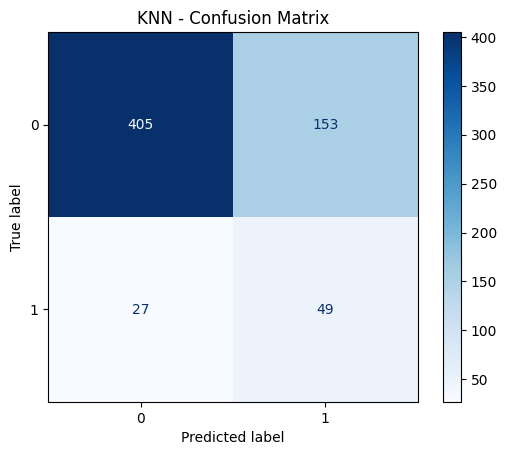


🔹 Training Naive Bayes...
ROC-AUC: 0.7704
F1-Score: 0.3508
              precision    recall  f1-score   support

         0.0       0.95      0.66      0.78       558
         1.0       0.23      0.75      0.35        76

    accuracy                           0.67       634
   macro avg       0.59      0.70      0.56       634
weighted avg       0.86      0.67      0.73       634



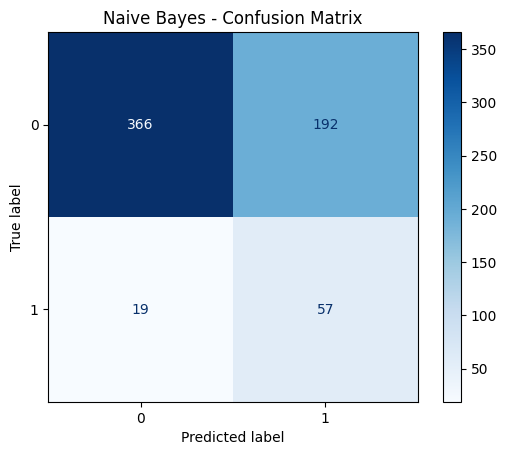


🔹 Training SVM...
ROC-AUC: 0.7854
F1-Score: 0.3734
              precision    recall  f1-score   support

         0.0       0.96      0.68      0.79       558
         1.0       0.25      0.78      0.37        76

    accuracy                           0.69       634
   macro avg       0.60      0.73      0.58       634
weighted avg       0.87      0.69      0.74       634



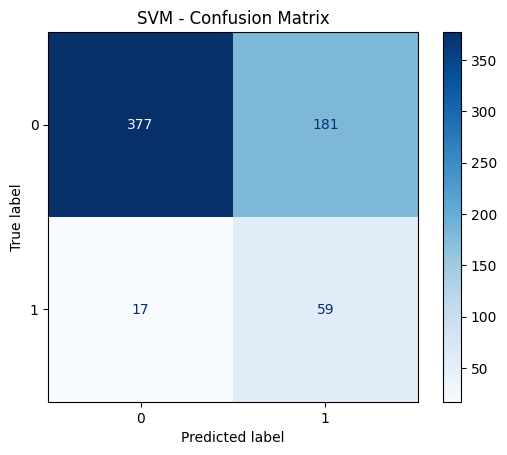


🔹 Training XGBoost...
ROC-AUC: 0.7788
F1-Score: 0.3173
              precision    recall  f1-score   support

         0.0       0.91      0.82      0.87       558
         1.0       0.25      0.43      0.32        76

    accuracy                           0.78       634
   macro avg       0.58      0.63      0.59       634
weighted avg       0.83      0.78      0.80       634



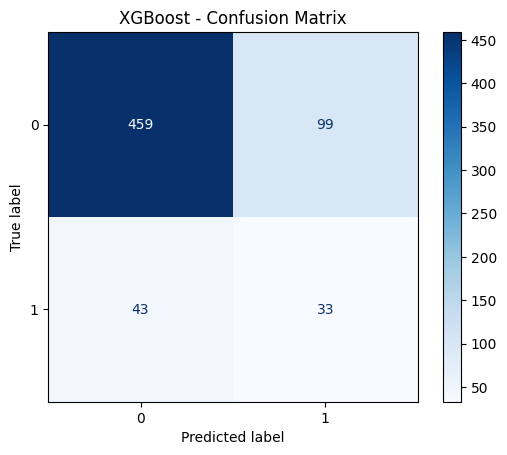


🏆 BEST MODEL: Logistic Regression with ROC-AUC: 0.7942


In [ ]:
results = train_and_evaluate_model_SMOTE(models, X_train, y_train, X_test, y_test)

# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression

# 1. Define the features (Ensure these match your X_train)
numeric_features = ['Age', 'Gender', 'Weight_kg', 'Systolic_BP', 'Diastolic_BP', 
                    'HbA1c', 'FBS', 'Cholesterol_Total', 'HDL']

# 2. Create the Preprocessor with an Imputer
# This will fill any missing values in the hospital data with the MEAN of the training data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', ImbPipeline([
            ('imputer', SimpleImputer(strategy='mean')), 
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)

# 3. Reconstruct the Best Pipe (Logistic Regression)
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', SMOTE(random_state=42)),
    ('under', RandomUnderSampler(random_state=42)),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=0.1,
        class_weight='balanced'
    ))
])

# Fit the pipe on your original training data
best_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('over', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Loading training data...
Training model...

Processing Hospital (CCMC) Data...
------------------------------
HOSPITAL DATA RESULTS
Total Patients: 163
Correct: 138 (84.66%)
Wrong: 25 (15.34%)
------------------------------


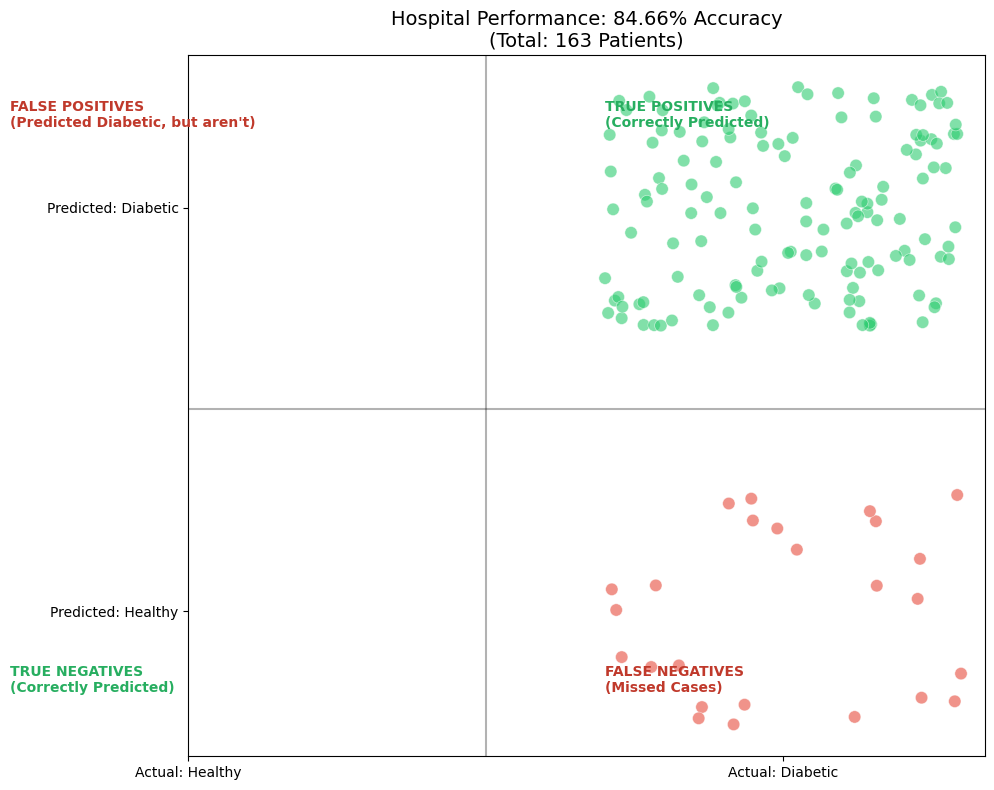

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression

# ==========================================
# 1. LOAD & PREPARE TRAINING DATA
# ==========================================
print("Loading training data...")
train_df = pd.read_csv('merged_data.csv')

# Define features used in training
numeric_features = ['Age', 'Gender', 'Weight_kg', 'Systolic_BP', 'Diastolic_BP', 
                    'HbA1c', 'FBS', 'Cholesterol_Total', 'HDL']

# Map target (NHANES: 1=Diabetic, 2=Non-Diabetic -> 1=Positive, 0=Negative)
train_df['Diabetes_Status'] = train_df['Diabetes_Status'].map({1: 1, 2: 0})
train_df = train_df.dropna(subset=['Diabetes_Status'])

X = train_df[numeric_features]
y = train_df['Diabetes_Status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', ImbPipeline([
            ('imputer', SimpleImputer(strategy='mean')), 
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)

best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', SMOTE(random_state=42)),
    ('under', RandomUnderSampler(random_state=42)),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=0.1,
        class_weight='balanced'
    ))
])


print("Training model")
best_pipe.fit(X_train, y_train)

ccmc = pd.read_excel('ccmc_dataset/COMPILED_DATASET.xlsx')


ccmc = ccmc.dropna(subset=['HbA1c'])


if ccmc['Gender'].dtype == 'object':
    ccmc['Gender'] = ccmc['Gender'].astype(str).str.upper().str.strip()
    ccmc['Gender'] = ccmc['Gender'].map({'M': 1, 'MALE': 1, 'F': 2, 'FEMALE': 2})


for col in numeric_features:
    if col in ccmc.columns and col != 'Gender':
        ccmc[col] = pd.to_numeric(ccmc[col].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')


ccmc['y_true'] = ccmc['Diabetes_Status'].fillna(0).astype(int)


X_hospital = ccmc[numeric_features]

ccmc['y_pred'] = best_pipe.predict(X_hospital)
ccmc['risk_score'] = best_pipe.predict_proba(X_hospital)[:, 1]


total = len(ccmc)
correct = (ccmc['y_pred'] == ccmc['y_true']).sum()
wrong = total - correct
accuracy = (correct / total) * 100

print("-" * 30)
print(f"HOSPITAL DATA RESULTS")
print(f"Total Patients: {total}")
print(f"Correct: {correct} ({accuracy:.2f}%)")
print(f"Wrong: {wrong} ({100 - accuracy:.2f}%)")
print("-" * 30)


plt.figure(figsize=(10, 8))

xjitter = ccmc['y_true'] + np.random.uniform(-0.3, 0.3, size=len(ccmc))
yjitter = ccmc['y_pred'] + np.random.uniform(-0.3, 0.3, size=len(ccmc))


colors = ['#2ecc71' if row['y_pred'] == row['y_true'] else '#e74c3c' for _, row in ccmc.iterrows()]

plt.scatter(xjitter, yjitter, c=colors, s=80, alpha=0.6, edgecolors='white', linewidth=0.5)


plt.axhline(y=0.5, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0.5, color='black', linestyle='-', alpha=0.3)


plt.text(-0.3, 1.2, "FALSE POSITIVES\n(Predicted Diabetic, but aren't)", color='#c0392b', fontweight='bold')
plt.text(0.7, 1.2, "TRUE POSITIVES\n(Correctly Predicted)", color='#27ae60', fontweight='bold')
plt.text(-0.3, -0.2, "TRUE NEGATIVES\n(Correctly Predicted)", color='#27ae60', fontweight='bold')
plt.text(0.7, -0.2, "FALSE NEGATIVES\n(Missed Cases)", color='#c0392b', fontweight='bold')

plt.xticks([0, 1], ["Actual: Healthy", "Actual: Diabetic"])
plt.yticks([0, 1], ["Predicted: Healthy", "Predicted: Diabetic"])
plt.title(f"Hospital Performance: {accuracy:.2f}% Accuracy\n(Total: {total} Patients)", fontsize=14)
plt.grid(False)

plt.tight_layout()
plt.show()